In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [13]:
df= pd.read_csv('placement data.csv')

In [14]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [16]:
df.shape

(100, 4)

In [17]:
df = df.iloc[:,1:]

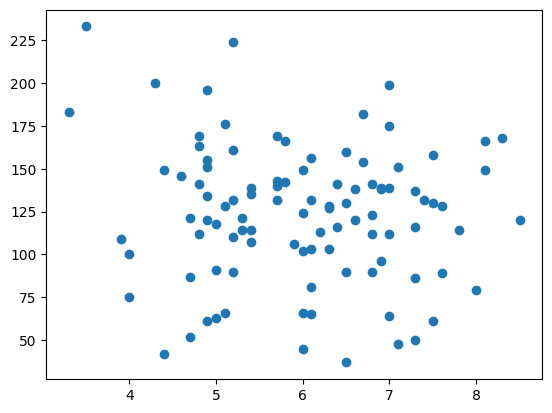

In [20]:
plt.scatter(df['cgpa'],df['iq'])

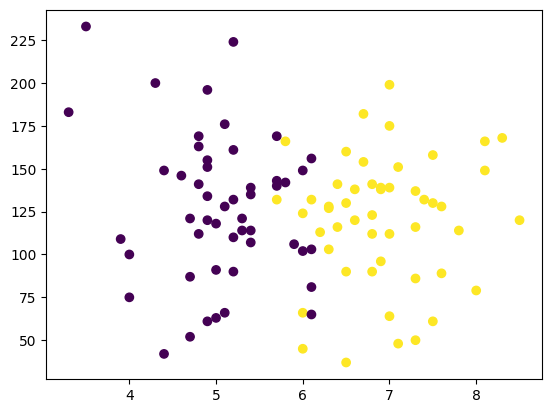

In [21]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [22]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

X = df.iloc[:,0:2] selects all rows and columns 0 and 1 as input features (independent variables).
y = df.iloc[:,-1] selects all rows and the last column as the target variable (output to be predicted).

Example:
Column index:   0          1          2
              Height     Weight     Disease
X = columns 0:2 → Height, Weight
y = column -1 → Disease (last column)


In [24]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [27]:
y.shape

(100,)

In [28]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [29]:
X_train

,cgpa,iq
5,7.1,48.0
75,4.8,169.0
44,7.5,61.0
12,5.4,139.0
93,6.8,112.0
...,...,...
92,5.2,110.0
57,6.5,130.0
11,6.9,138.0
4,5.8,142.0


In [30]:
y_train

,placement
5,1
75,0
44,1
12,0
93,1
...,...
92,0
57,1
11,1
4,0


In [31]:
X_test

,cgpa,iq
81,5.4,107.0
98,6.3,103.0
76,4.9,155.0
79,6.5,90.0
97,6.7,182.0
78,6.1,81.0
65,8.1,166.0
22,4.9,120.0
18,4.0,100.0
43,6.8,141.0


In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()

In [34]:
X_train = scaler.fit_transform(X_train)

In [35]:
X_train

array([[ 0.97137499, -1.86602705],
       [-1.04744653,  1.12543984],
       [ 1.32247439, -1.54462978],
       [-0.52079744,  0.38375383],
       [ 0.70805045, -0.28376357],
       [-1.39854592,  0.6309825 ],
       [-0.78412198,  0.1118023 ],
       [ 1.32247439,  0.8534883 ],
       [ 0.09362651, -1.44573831],
       [-0.95967168,  0.68042824],
       [ 0.88360014,  1.27377704],
       [-1.48632077,  1.89184871],
       [-0.87189683, -0.80294378],
       [ 1.23469954,  0.21069377],
       [ 1.76134863, -1.09961818],
       [ 0.2691762 ,  0.1118023 ],
       [-0.52079744, -0.23431784],
       [-0.25747289,  0.4084767 ],
       [ 0.18140135, -0.2590407 ],
       [-1.13522138, -0.06125777],
       [ 0.88360014,  1.86712584],
       [ 2.20022287, -0.08598064],
       [ 0.79582529, -0.67932944],
       [ 0.79582529,  0.38375383],
       [ 1.14692469,  0.3343081 ],
       [-1.83742016, -0.35793217],
       [ 0.00585166,  0.01291083],
       [ 1.14692469, -0.92655811],
       [-0.08192319,

In [36]:
X_test = scaler.transform(X_test)

In [37]:
X_test

array([[-0.52079744, -0.40737791],
       [ 0.2691762 , -0.50626937],
       [-0.95967168,  0.7793197 ],
       [ 0.4447259 , -0.82766664],
       [ 0.6202756 ,  1.44683711],
       [ 0.09362651, -1.05017244],
       [ 1.84912348,  1.05127124],
       [-0.95967168, -0.08598064],
       [-1.74964532, -0.58043797],
       [ 0.70805045,  0.43319957]])

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
clf = LogisticRegression()

In [42]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [43]:
y_pred = clf.predict(X_test)


In [44]:
y_test

,placement
81,0
98,1
76,0
79,1
97,1
78,0
65,1
22,0
18,0
43,1


In [45]:
from sklearn.metrics import accuracy_score

In [46]:
accuracy_score(y_test,y_pred)

0.9

In [47]:
from mlxtend.plotting import plot_decision_regions

In [48]:
clf.predict(X_test)

array([0, 1, 0, 1, 1, 1, 1, 0, 0, 1])

<Axes: >

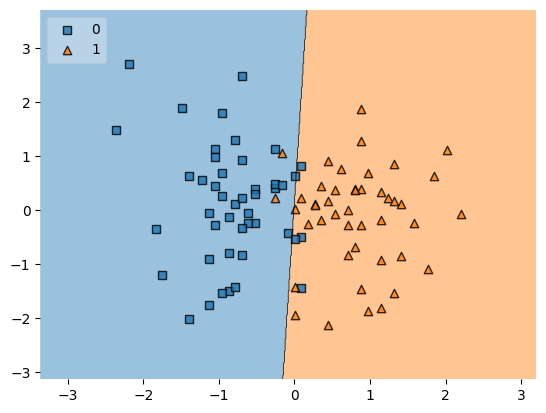

In [49]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [50]:
import pickle

In [51]:
pickle.dump(clf,open('model.pkl','wb'))